# Correlation Analysis of Student Mental Health Variables

This notebook creates comprehensive correlation visualizations for all variables in the Data_Clean folder.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10


## Load and Prepare Data


In [16]:
# Load EMA data files
mood_df = pd.read_csv("EMA/Mood.csv")
stress_df = pd.read_csv("EMA/Stress.csv")
sleep_df = pd.read_csv("EMA/Sleep.csv")
exercise_df = pd.read_csv("EMA/Exercise.csv")
social_df = pd.read_csv("EMA/Social.csv")
behavior_df = pd.read_csv("EMA/Behavior.csv")

# Load static data
phq9_df = pd.read_csv("static/clean_PHQ-9.csv")
grades_df = pd.read_csv("static/grades.csv")

print("Data loaded successfully!")
print(f"Mood: {mood_df.shape}")
print(f"Stress: {stress_df.shape}")
print(f"Sleep: {sleep_df.shape}")
print(f"Exercise: {exercise_df.shape}")
print(f"Social: {social_df.shape}")
print(f"Behavior: {behavior_df.shape}")
print(f"PHQ-9: {phq9_df.shape}")
print(f"Grades: {grades_df.shape}")


Data loaded successfully!
Mood: (276, 7)
Stress: (2167, 4)
Sleep: (1644, 7)
Exercise: (763, 11)
Social: (1410, 5)
Behavior: (454, 12)
PHQ-9: (84, 14)
Grades: (30, 4)


## Aggregate Data by User


In [17]:
# Function to aggregate numeric columns by user_id
def aggregate_by_user(df, user_col="user_id", agg_method="mean"):
    """Aggregate numeric columns by user_id"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if user_col in numeric_cols:
        numeric_cols.remove(user_col)

    if len(numeric_cols) == 0:
        return pd.DataFrame()

    if agg_method == "mean":
        aggregated = df.groupby(user_col)[numeric_cols].mean().reset_index()
    elif agg_method == "median":
        aggregated = df.groupby(user_col)[numeric_cols].median().reset_index()
    else:
        aggregated = df.groupby(user_col)[numeric_cols].agg(agg_method).reset_index()

    return aggregated


# Aggregate each dataset
mood_agg = aggregate_by_user(mood_df, "user_id", "mean")
stress_agg = aggregate_by_user(stress_df, "user_id", "mean")
sleep_agg = aggregate_by_user(sleep_df, "user_id", "mean")
exercise_agg = aggregate_by_user(exercise_df, "user_id", "mean")
social_agg = aggregate_by_user(social_df, "user_id", "mean")
behavior_agg = aggregate_by_user(behavior_df, "user_id", "mean")

# Prepare PHQ-9 data (already has uid column)
phq9_numeric = phq9_df.select_dtypes(include=[np.number]).columns.tolist()
phq9_agg = phq9_df.groupby("uid")[phq9_numeric].mean().reset_index()
phq9_agg = phq9_agg.rename(columns={"uid": "user_id"})

# Prepare grades data
grades_agg = grades_df.rename(columns={"uid": "user_id"})

print("Data aggregated successfully!")


Data aggregated successfully!


## Merge All Data


In [18]:
# Merge all datasets on user_id
merged_df = mood_agg.copy()

# Add prefix to column names to avoid conflicts
datasets = {
    "stress": (stress_agg, "stress_"),
    "sleep": (sleep_agg, "sleep_"),
    "exercise": (exercise_agg, "exercise_"),
    "social": (social_agg, "social_"),
    "behavior": (behavior_agg, "behavior_"),
    "phq9": (phq9_agg, "phq9_"),
    "grades": (grades_agg, "grades_"),
}

for name, (df, prefix) in datasets.items():
    if not df.empty:
        df_prefixed = df.copy()
        # Don't prefix user_id
        cols_to_prefix = [col for col in df_prefixed.columns if col != "user_id"]
        df_prefixed = df_prefixed.rename(columns={col: prefix + col for col in cols_to_prefix})
        merged_df = pd.merge(merged_df, df_prefixed, on="user_id", how="outer")

# Also add mood prefix for consistency
mood_cols = [
    col
    for col in merged_df.columns
    if col not in ["user_id"]
    and not col.startswith(
        ("stress_", "sleep_", "exercise_", "social_", "behavior_", "phq9_", "grades_")
    )
]
merged_df = merged_df.rename(columns={col: "mood_" + col for col in mood_cols if col != "user_id"})

print(f"Merged dataset shape: {merged_df.shape}")
print(f"\nColumns: {list(merged_df.columns)}")


Merged dataset shape: (49, 47)

Columns: ['user_id', 'mood_happy', 'mood_happyornot', 'mood_resp_time', 'mood_sad', 'mood_sadornot', 'stress_level', 'stress_resp_time', 'sleep_resp_time', 'sleep_sleep_hours', 'sleep_sleep_quality', 'sleep_sleepiness', 'exercise_hour', 'exercise_exercise', 'exercise_walk', 'exercise_have', 'exercise_schedule', 'exercise_latitude', 'exercise_longitude', 'exercise_has_location', 'social_resp_time', 'social_number', 'behavior_anxious', 'behavior_calm', 'behavior_conventional', 'behavior_critical', 'behavior_dependable', 'behavior_disorganized', 'behavior_enthusiastic', 'behavior_experiences', 'behavior_reserved', 'behavior_resp_time', 'behavior_sympathetic', 'phq9_Little interest or pleasure in doing things', 'phq9_Feeling down, depressed, hopeless.', 'phq9_Trouble falling or staying asleep, or sleeping too much.', 'phq9_Feeling tired or having little energy', 'phq9_Poor appetite or overeating', 'phq9_Feeling bad about yourself or that you are a failure or

## Calculate Correlation Matrix


In [19]:
# Select only numeric columns for correlation
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
corr_df = merged_df[numeric_cols]

# Calculate correlation matrix
correlation_matrix = corr_df.corr()

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print(f"\nNumber of variables: {len(numeric_cols)}")


# Create readable variable name mapping
def create_readable_names(col_name):
    """Convert variable names to more readable format"""
    # Remove prefixes and convert to readable names
    name = col_name

    # PHQ-9 specific mappings (long question names)
    phq9_mappings = {
        "phq9_Little interest or pleasure in doing things": "PHQ9: Little Interest",
        "phq9_Feeling down, depressed, hopeless.": "PHQ9: Feeling Down",
        "phq9_Trouble falling or staying asleep, or sleeping too much.": "PHQ9: Sleep Problems",
        "phq9_Feeling tired or having little energy": "PHQ9: Tired/Low Energy",
        "phq9_Poor appetite or overeating": "PHQ9: Appetite Issues",
        "phq9_Feeling bad about yourself or that you are a failure or have let yourself or your family down": "PHQ9: Self-Worth",
        "phq9_Trouble concentrating on things, such as reading the newspaper or watching television": "PHQ9: Concentration",
        "phq9_Moving or speaking so slowly that other people could have noticed. Or the opposite being so figety or restless that you have been moving around a lot more than usual": "PHQ9: Movement Issues",
        "phq9_Thoughts that you would be better off dead, or of hurting yourself": "PHQ9: Suicidal Thoughts",
        "phq9_Response": "PHQ9: Response",
        "phq9_total_score": "PHQ9: Total Score",
    }

    if name in phq9_mappings:
        return phq9_mappings[name]

    # Remove prefixes and format
    if name.startswith("mood_"):
        base = name.replace("mood_", "")
        if base == "happy":
            return "Mood: Happy"
        elif base == "happyornot":
            return "Mood: Happy (Binary)"
        elif base == "sad":
            return "Mood: Sad"
        elif base == "sadornot":
            return "Mood: Sad (Binary)"
        elif base == "resp_time":
            return "Mood: Response Time"
        else:
            return f"Mood: {base.title()}"

    elif name.startswith("stress_"):
        base = name.replace("stress_", "")
        if base == "level":
            return "Stress: Level"
        elif base == "resp_time":
            return "Stress: Response Time"
        else:
            return f"Stress: {base.title()}"

    elif name.startswith("sleep_"):
        base = name.replace("sleep_", "")
        if base == "sleep_hours":
            return "Sleep: Hours"
        elif base == "sleep_quality":
            return "Sleep: Quality"
        elif base == "sleepiness":
            return "Sleep: Sleepiness"
        elif base == "resp_time":
            return "Sleep: Response Time"
        else:
            return f"Sleep: {base.title()}"

    elif name.startswith("exercise_"):
        base = name.replace("exercise_", "")
        if base == "exercise":
            return "Exercise: Level"
        elif base == "walk":
            return "Exercise: Walk"
        elif base == "have":
            return "Exercise: Have"
        elif base == "schedule":
            return "Exercise: Scheduled"
        elif base == "hour":
            return "Exercise: Hour"
        elif base == "latitude":
            return "Exercise: Latitude"
        elif base == "longitude":
            return "Exercise: Longitude"
        elif base == "has_location":
            return "Exercise: Has Location"
        elif base == "resp_time":
            return "Exercise: Response Time"
        else:
            return f"Exercise: {base.title()}"

    elif name.startswith("social_"):
        base = name.replace("social_", "")
        if base == "number":
            return "Social: Number"
        elif base == "resp_time":
            return "Social: Response Time"
        else:
            return f"Social: {base.title()}"

    elif name.startswith("behavior_"):
        base = name.replace("behavior_", "")
        if base == "anxious":
            return "Behavior: Anxious"
        elif base == "calm":
            return "Behavior: Calm"
        elif base == "conventional":
            return "Behavior: Conventional"
        elif base == "critical":
            return "Behavior: Critical"
        elif base == "dependable":
            return "Behavior: Dependable"
        elif base == "disorganized":
            return "Behavior: Disorganized"
        elif base == "enthusiastic":
            return "Behavior: Enthusiastic"
        elif base == "experiences":
            return "Behavior: Experiences"
        elif base == "reserved":
            return "Behavior: Reserved"
        elif base == "sympathetic":
            return "Behavior: Sympathetic"
        elif base == "resp_time":
            return "Behavior: Response Time"
        else:
            return f"Behavior: {base.title()}"

    elif name.startswith("grades_"):
        base = name.replace("grades_", "")
        if base == "gpa all":
            return "GPA: Overall"
        elif base == "gpa 13s":
            return "GPA: 13s"
        elif base == "cs 65":
            return "Grade: CS 65"
        else:
            return f"Grade: {base.title()}"

    else:
        return name.title()


# Create readable name mapping
readable_names = {col: create_readable_names(col) for col in numeric_cols}

# Rename correlation matrix columns and index
correlation_matrix_readable = correlation_matrix.copy()
correlation_matrix_readable.columns = [
    readable_names.get(col, col) for col in correlation_matrix_readable.columns
]
correlation_matrix_readable.index = [
    readable_names.get(idx, idx) for idx in correlation_matrix_readable.index
]

print("\nVariable names converted to readable format!")


Correlation matrix shape: (46, 46)

Number of variables: 46

Variable names converted to readable format!


## Visualization 1: Full Correlation Heatmap


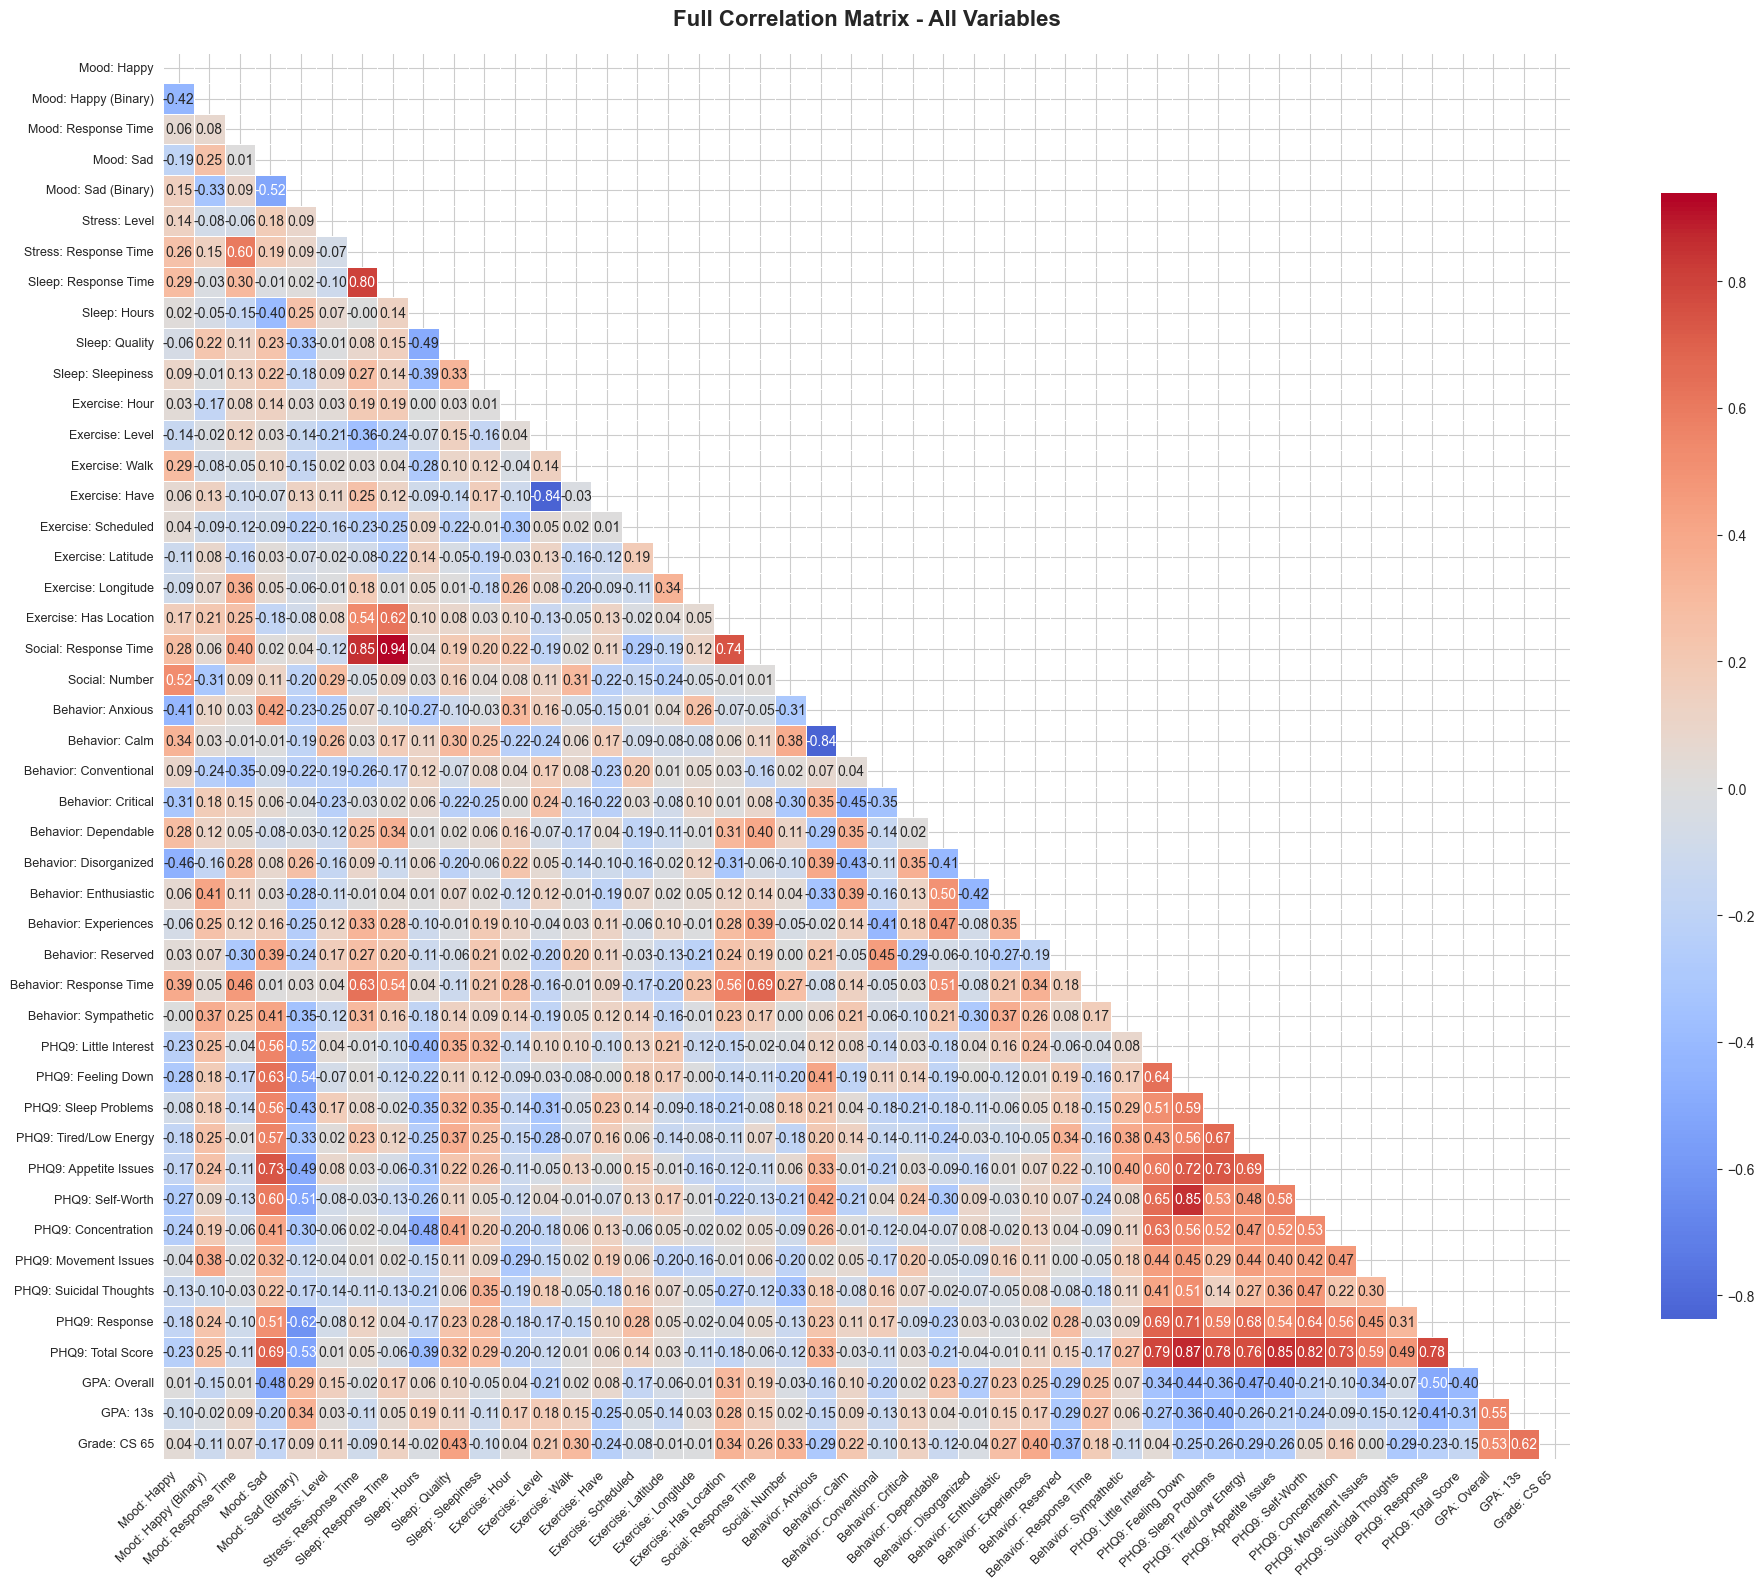

In [20]:
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix_readable, dtype=bool))  # Mask upper triangle
sns.heatmap(
    correlation_matrix_readable,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    xticklabels=True,
    yticklabels=True,
)
plt.title("Full Correlation Matrix - All Variables", fontsize=16, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_heatmap_full.png", dpi=300, bbox_inches="tight")
plt.show()


## Visualization 2: Correlation Heatmap by Category


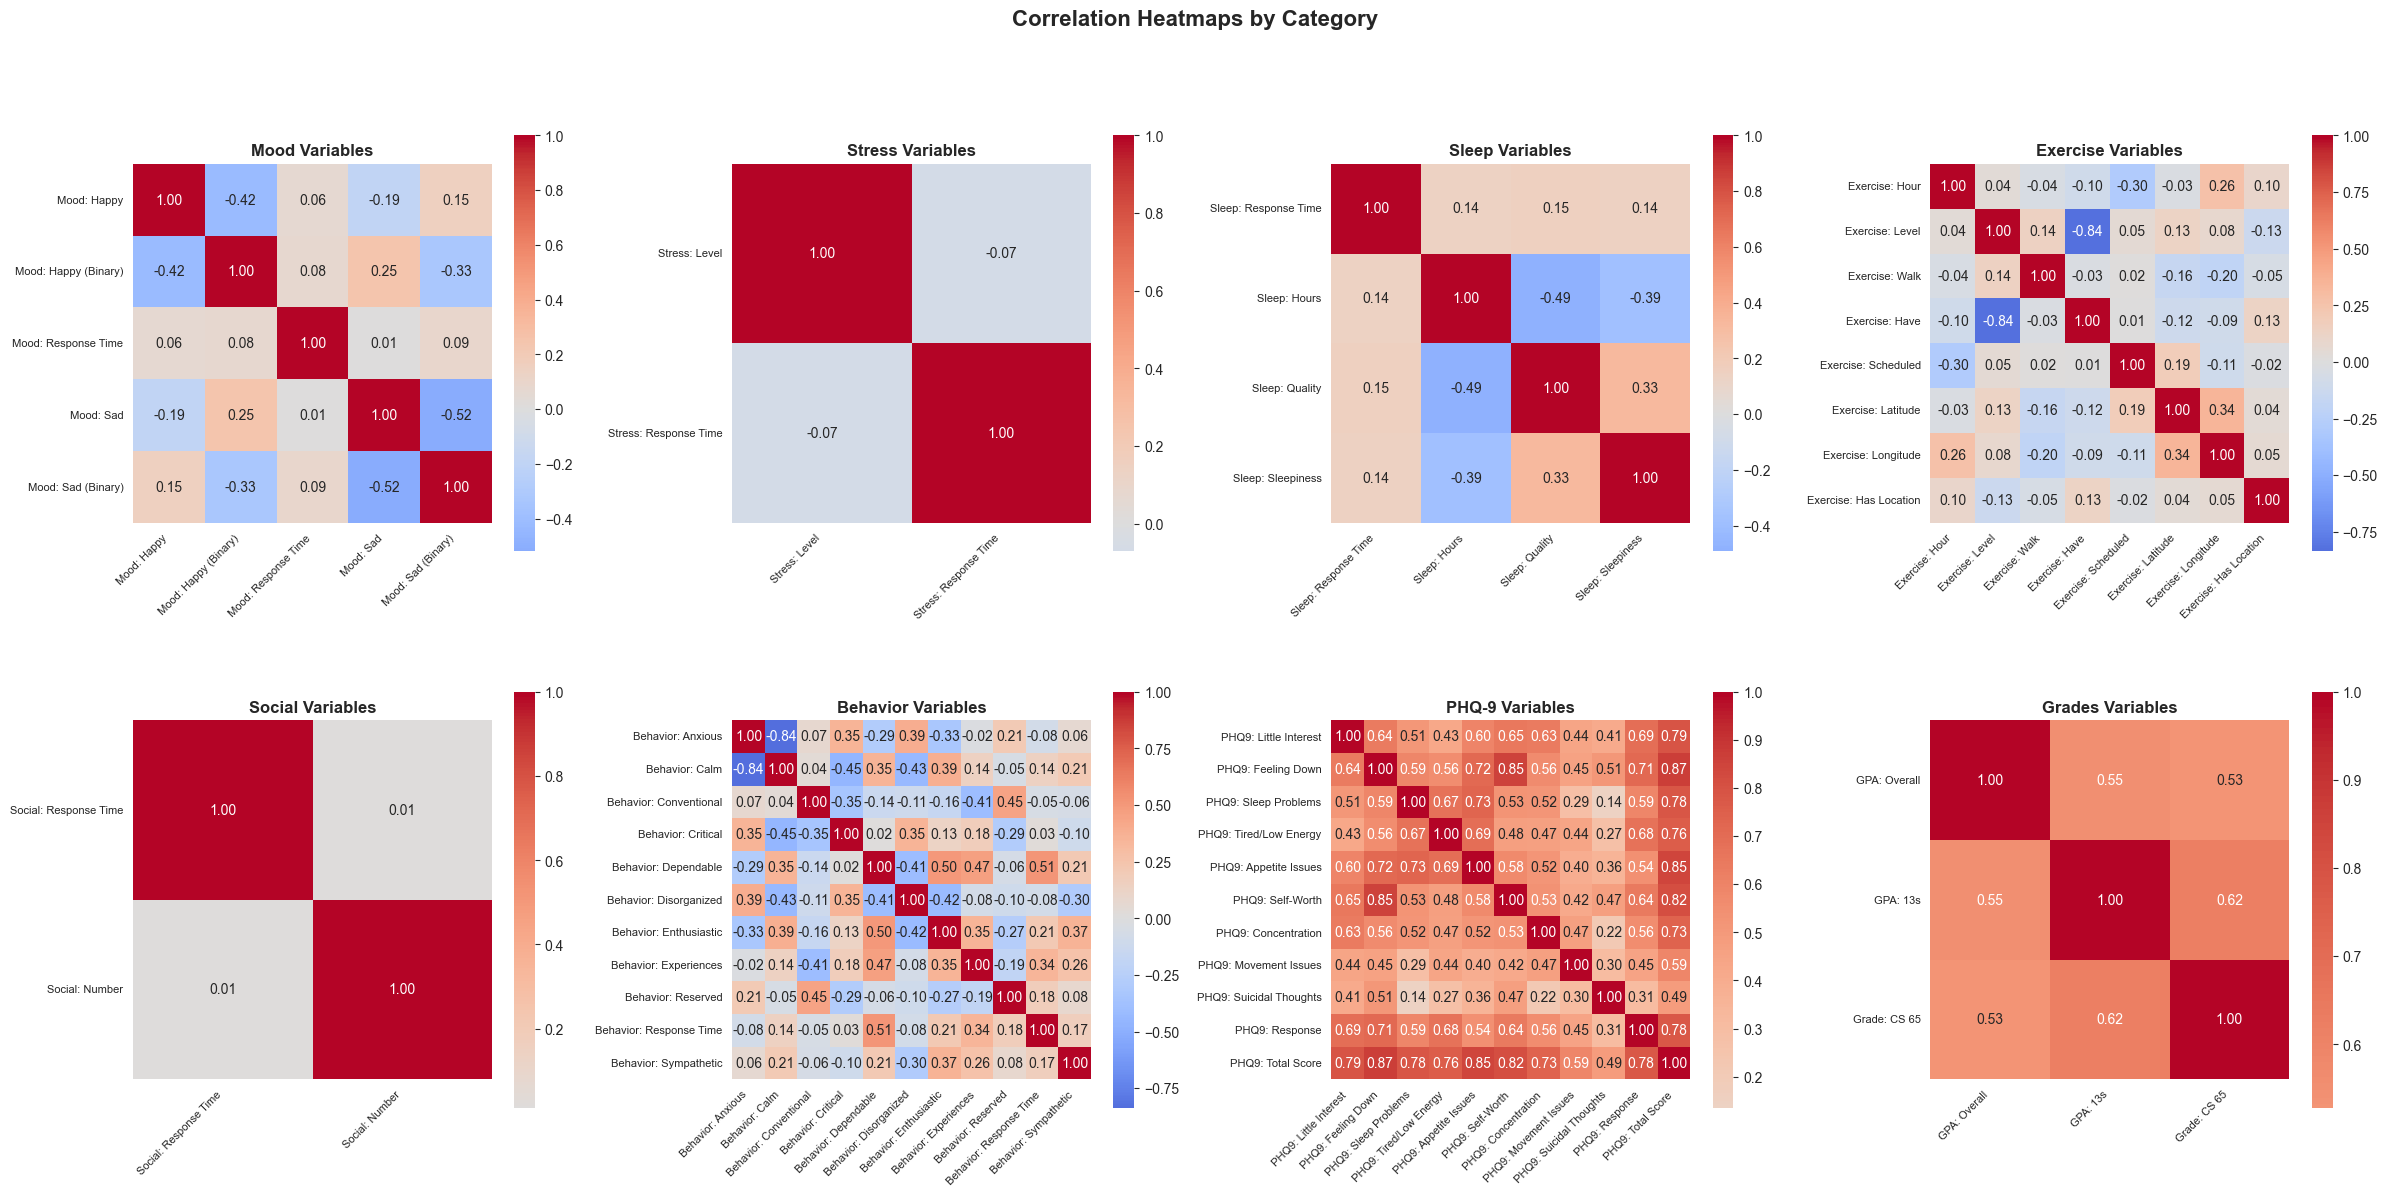

In [21]:
# Group variables by category (using original names for filtering)
categories_original = {
    "Mood": [col for col in numeric_cols if col.startswith("mood_")],
    "Stress": [col for col in numeric_cols if col.startswith("stress_")],
    "Sleep": [col for col in numeric_cols if col.startswith("sleep_")],
    "Exercise": [col for col in numeric_cols if col.startswith("exercise_")],
    "Social": [col for col in numeric_cols if col.startswith("social_")],
    "Behavior": [col for col in numeric_cols if col.startswith("behavior_")],
    "PHQ-9": [col for col in numeric_cols if col.startswith("phq9_")],
    "Grades": [col for col in numeric_cols if col.startswith("grades_")],
}

# Convert to readable names for each category
categories = {}
for cat_name, orig_cols in categories_original.items():
    categories[cat_name] = [readable_names.get(col, col) for col in orig_cols]

# Create a figure with subplots for each category
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, (category, cols) in enumerate(categories.items()):
    if len(cols) > 0:
        cat_corr = correlation_matrix_readable.loc[cols, cols]
        if cat_corr.shape[0] > 0:
            sns.heatmap(
                cat_corr,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                center=0,
                square=True,
                ax=axes[idx],
                cbar_kws={"shrink": 0.8},
            )
            axes[idx].set_title(f"{category} Variables", fontsize=12, fontweight="bold")
            axes[idx].set_xticklabels(
                axes[idx].get_xticklabels(), rotation=45, ha="right", fontsize=8
            )
            axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0, fontsize=8)
    else:
        axes[idx].axis("off")

plt.suptitle("Correlation Heatmaps by Category", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("correlation_heatmap_by_category.png", dpi=300, bbox_inches="tight")
plt.show()


## Visualization 3: Cross-Category Correlations


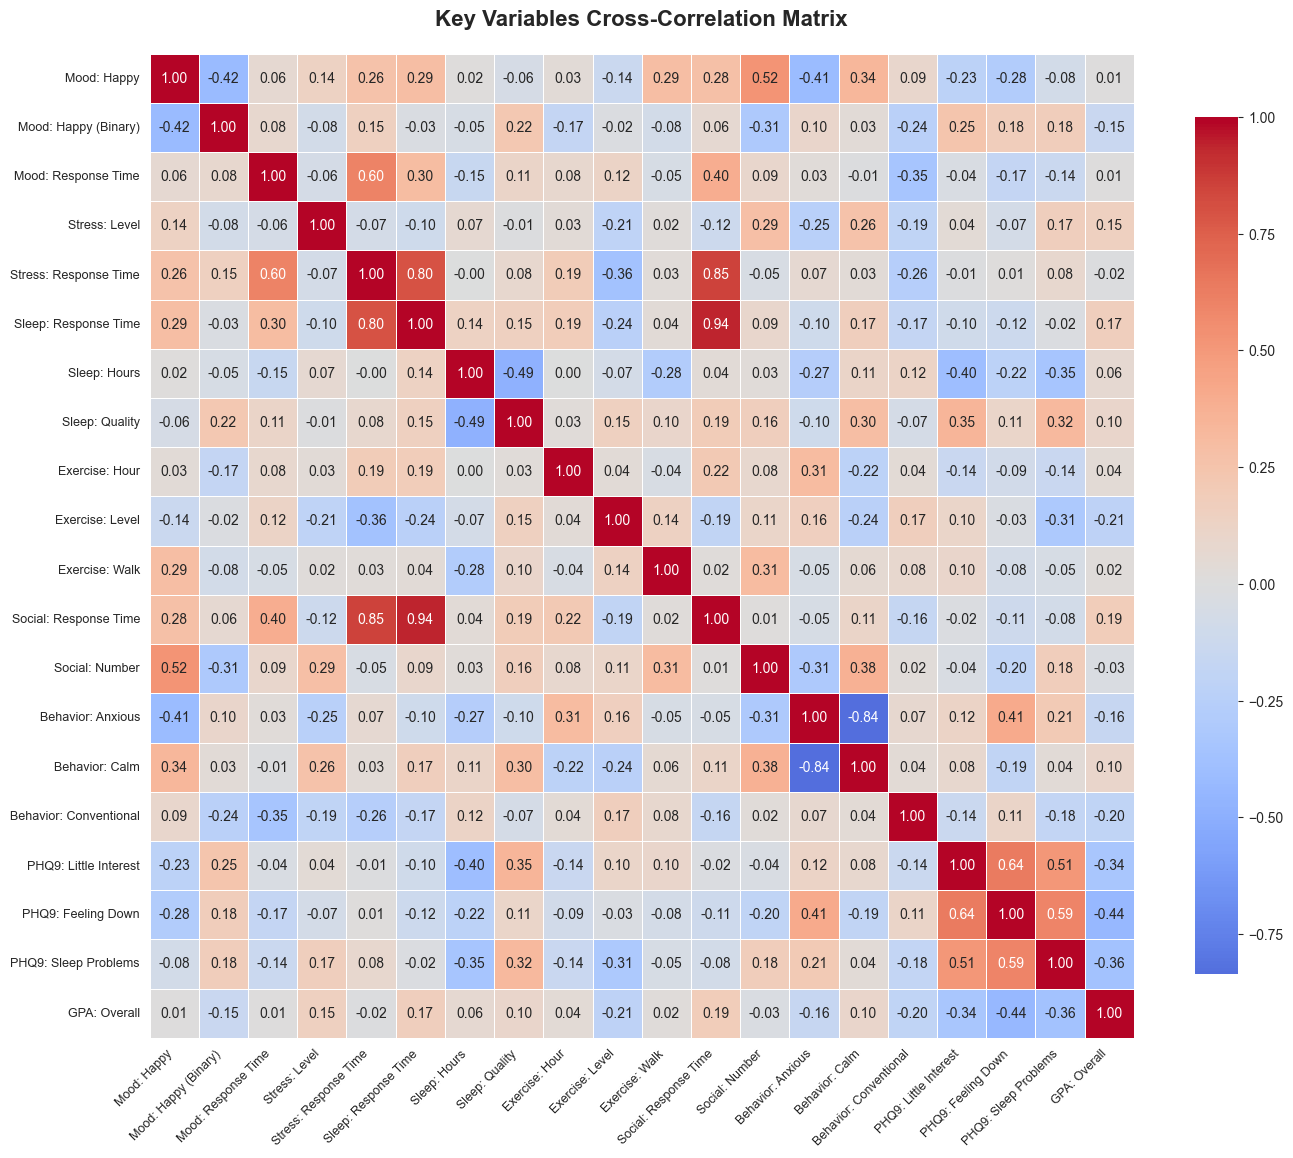

In [22]:
# Focus on key variables and their cross-correlations
key_vars = []
for category, cols in categories.items():
    if len(cols) > 0:
        # Take first few variables from each category
        key_vars.extend(cols[:3])

# Limit to avoid overcrowding
if len(key_vars) > 20:
    key_vars = key_vars[:20]

key_corr = correlation_matrix_readable.loc[key_vars, key_vars]

plt.figure(figsize=(14, 12))
sns.heatmap(
    key_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Key Variables Cross-Correlation Matrix", fontsize=16, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_heatmap_key_variables.png", dpi=300, bbox_inches="tight")
plt.show()


## Visualization 4: Top Correlations


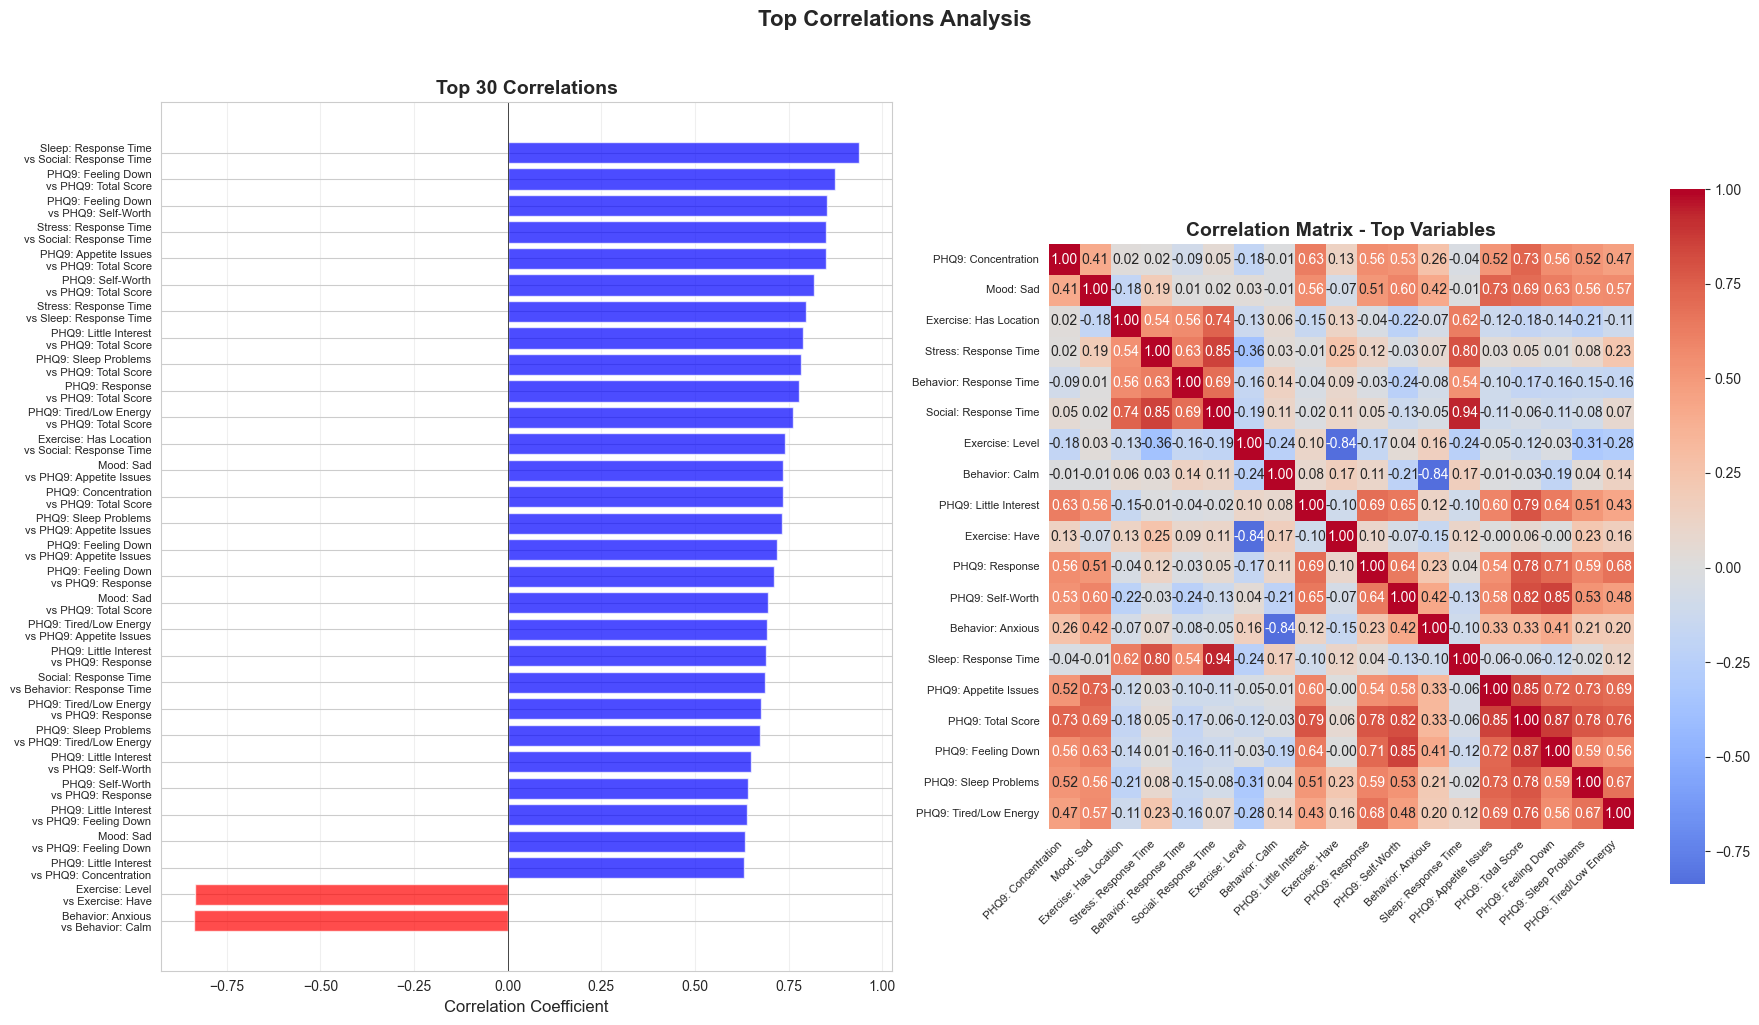


Top 30 Correlations:
            Variable 1              Variable 2  Correlation
  Sleep: Response Time   Social: Response Time     0.938237
    PHQ9: Feeling Down       PHQ9: Total Score     0.874922
    PHQ9: Feeling Down        PHQ9: Self-Worth     0.852839
 Stress: Response Time   Social: Response Time     0.851191
 PHQ9: Appetite Issues       PHQ9: Total Score     0.850939
     Behavior: Anxious          Behavior: Calm    -0.836301
       Exercise: Level          Exercise: Have    -0.835524
      PHQ9: Self-Worth       PHQ9: Total Score     0.817718
 Stress: Response Time    Sleep: Response Time     0.795801
 PHQ9: Little Interest       PHQ9: Total Score     0.787904
  PHQ9: Sleep Problems       PHQ9: Total Score     0.782230
        PHQ9: Response       PHQ9: Total Score     0.778047
PHQ9: Tired/Low Energy       PHQ9: Total Score     0.763128
Exercise: Has Location   Social: Response Time     0.739538
             Mood: Sad   PHQ9: Appetite Issues     0.734699
   PHQ9: Concentra

In [23]:
# Get top correlations (excluding self-correlations and duplicates)
def get_top_correlations(corr_matrix, n=20):
    """Extract top N correlations"""
    # Create a copy and set diagonal and upper triangle to NaN
    corr_copy = corr_matrix.copy()
    corr_copy = corr_copy.where(np.triu(np.ones(corr_copy.shape), k=1).astype(bool))

    # Stack and sort
    corr_pairs = corr_copy.stack().reset_index()
    corr_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]
    corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

    # Get top N by absolute value
    top_corr = corr_pairs.nlargest(n, "Abs_Correlation")
    return top_corr


top_correlations = get_top_correlations(correlation_matrix_readable, n=30)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# Plot 1: Bar chart of top correlations
top_corr_sorted = top_correlations.sort_values("Correlation", ascending=True)
colors = ["red" if x < 0 else "blue" for x in top_corr_sorted["Correlation"]]
ax1.barh(range(len(top_corr_sorted)), top_corr_sorted["Correlation"], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_corr_sorted)))
# Truncate long names for better display
labels = []
for _, row in top_corr_sorted.iterrows():
    v1 = row["Variable 1"][:25] + "..." if len(row["Variable 1"]) > 25 else row["Variable 1"]
    v2 = row["Variable 2"][:25] + "..." if len(row["Variable 2"]) > 25 else row["Variable 2"]
    labels.append(f"{v1}\nvs {v2}")
ax1.set_yticklabels(labels, fontsize=8)
ax1.set_xlabel("Correlation Coefficient", fontsize=12)
ax1.set_title("Top 30 Correlations", fontsize=14, fontweight="bold")
ax1.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
ax1.grid(axis="x", alpha=0.3)

# Plot 2: Heatmap of top correlations
top_vars = list(
    set(top_correlations["Variable 1"].tolist() + top_correlations["Variable 2"].tolist())
)
top_vars_corr = correlation_matrix_readable.loc[top_vars, top_vars]
sns.heatmap(
    top_vars_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax2,
    cbar_kws={"shrink": 0.8},
)
ax2.set_title("Correlation Matrix - Top Variables", fontsize=14, fontweight="bold")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle("Top Correlations Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("top_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

# Print top correlations
print("\nTop 30 Correlations:")
print(top_correlations[["Variable 1", "Variable 2", "Correlation"]].to_string(index=False))


## Visualization 5: Correlation with PHQ-9 Scores


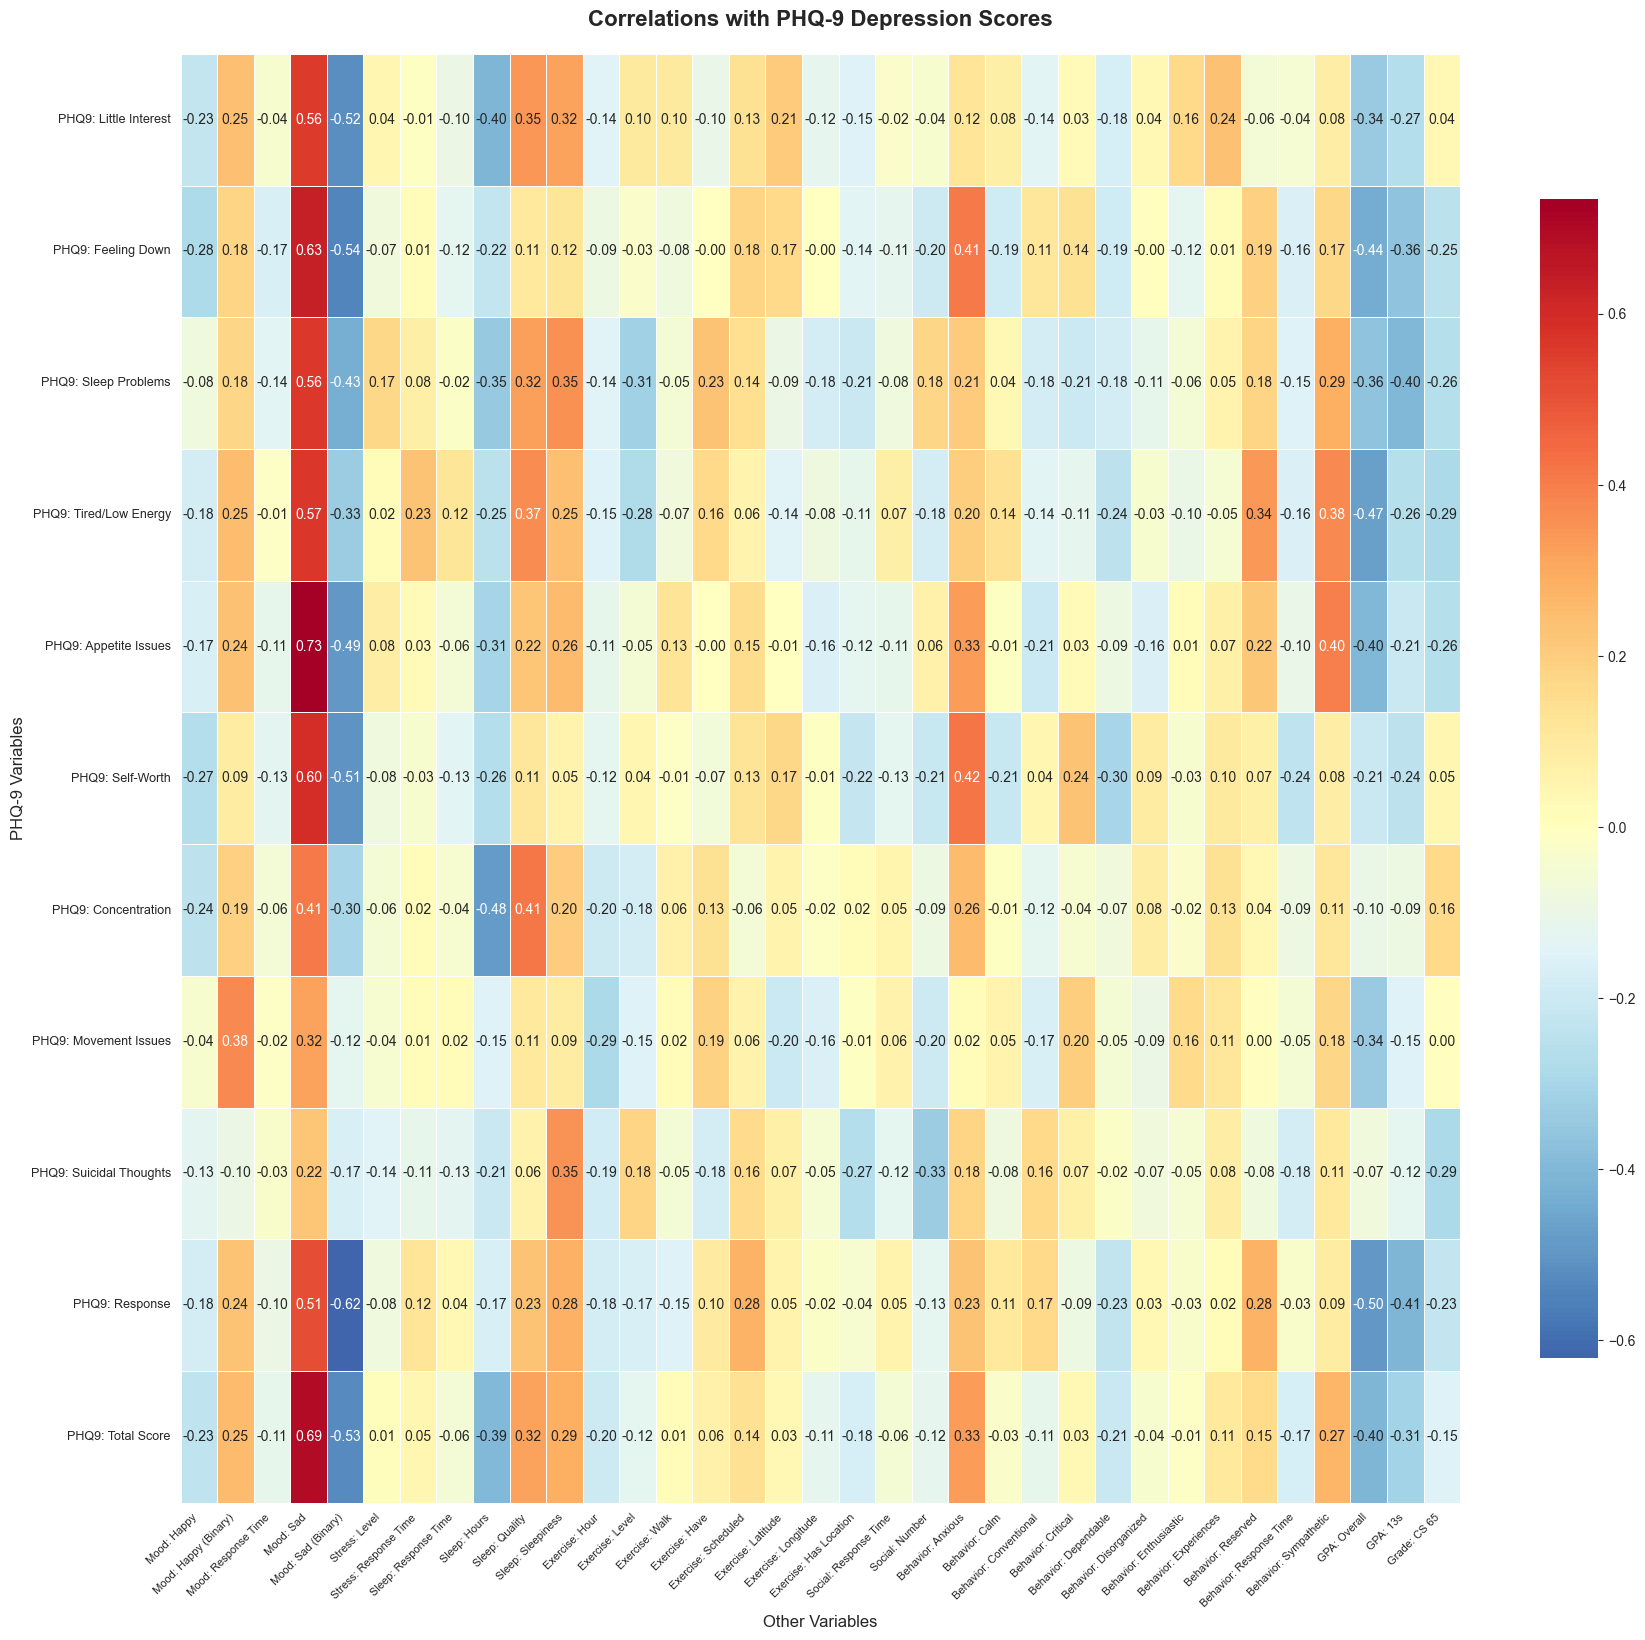


Top variables correlated with PHQ-9 Total Score:
Mood: Sad                0.694601
Behavior: Anxious        0.328523
Sleep: Quality           0.318478
Sleep: Sleepiness        0.287973
Behavior: Sympathetic    0.271578
Mood: Happy (Binary)     0.254035
Behavior: Reserved       0.153303
Exercise: Scheduled      0.139180
Behavior: Experiences    0.107374
Exercise: Have           0.064999
Stress: Response Time    0.046194
Behavior: Critical       0.033845
Exercise: Latitude       0.032613
Exercise: Walk           0.009999
Stress: Level            0.007269


In [24]:
# Focus on correlations with PHQ-9 variables (depression scores)
phq9_vars_original = [col for col in numeric_cols if col.startswith("phq9_")]
other_vars_original = [col for col in numeric_cols if not col.startswith("phq9_")]

# Convert to readable names
phq9_vars = [readable_names.get(col, col) for col in phq9_vars_original]
other_vars = [readable_names.get(col, col) for col in other_vars_original]

if len(phq9_vars) > 0 and len(other_vars) > 0:
    phq9_corr = correlation_matrix_readable.loc[phq9_vars, other_vars]

    plt.figure(figsize=(18, max(6, len(phq9_vars) * 1.5)))
    sns.heatmap(
        phq9_corr,
        annot=True,
        fmt=".2f",
        cmap="RdYlBu_r",
        center=0,
        square=False,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Correlations with PHQ-9 Depression Scores", fontsize=16, fontweight="bold", pad=20)
    plt.xlabel("Other Variables", fontsize=12)
    plt.ylabel("PHQ-9 Variables", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig("correlation_with_phq9.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Get top correlations with PHQ-9
    if "PHQ9: Total Score" in phq9_corr.index:
        phq9_total_corr = phq9_corr.loc["PHQ9: Total Score"].sort_values(ascending=False)
        print("\nTop variables correlated with PHQ-9 Total Score:")
        print(phq9_total_corr.head(15).to_string())


## Visualization 6: Pairwise Scatter Plots for Key Variables


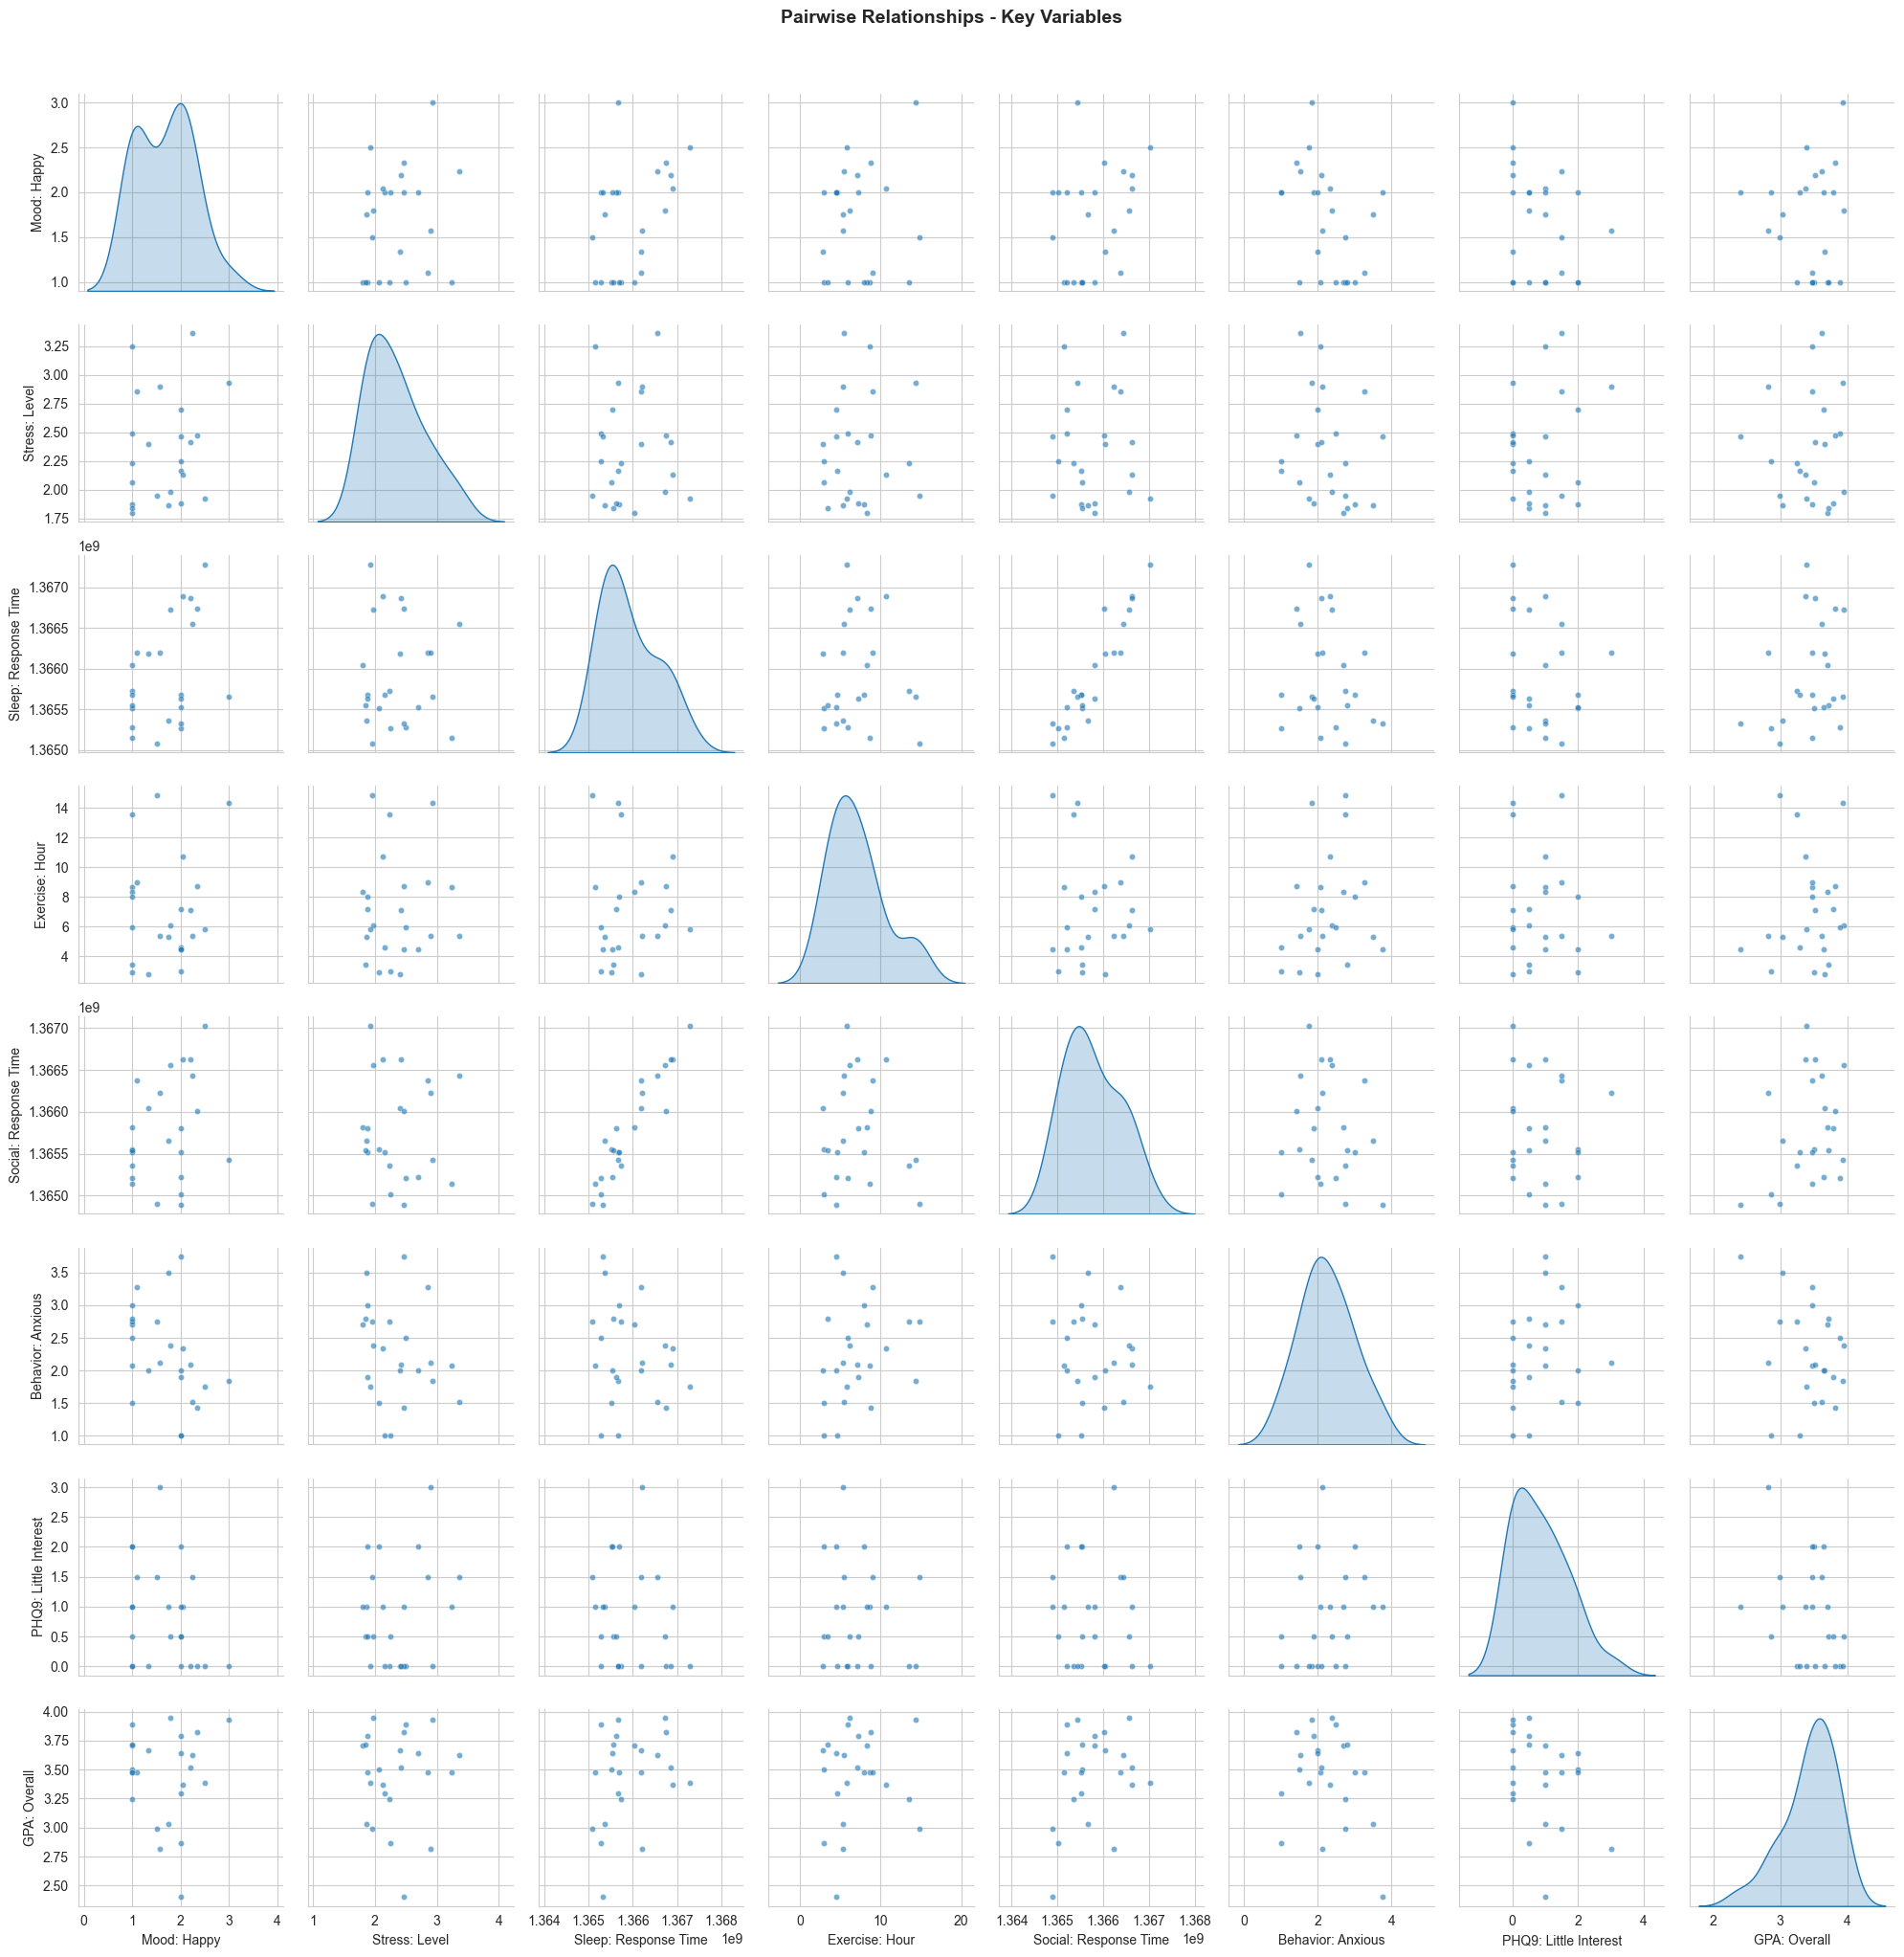

In [25]:
# Select a subset of key variables for pair plots (using readable names)
key_vars_readable = []
for category, cols in categories.items():
    if len(cols) > 0:
        key_vars_readable.append(cols[0])  # Take first variable from each category

# Limit to 6-8 variables for readability
if len(key_vars_readable) > 8:
    key_vars_readable = key_vars_readable[:8]

# Map back to original column names for data access
reverse_readable_names = {v: k for k, v in readable_names.items()}
key_vars_original = [reverse_readable_names.get(v, v) for v in key_vars_readable]

# Remove any variables with too many missing values
key_vars_original = [
    v for v in key_vars_original if v in merged_df.columns and merged_df[v].notna().sum() > 5
]
key_vars_readable = [readable_names.get(v, v) for v in key_vars_original]

if len(key_vars_original) >= 3:
    pair_data = merged_df[key_vars_original].dropna()
    # Rename columns to readable names for display
    pair_data_display = pair_data.copy()
    pair_data_display.columns = [readable_names.get(col, col) for col in pair_data_display.columns]

    if len(pair_data_display) > 0:
        # Create pair plot
        g = sns.pairplot(
            pair_data_display, diag_kind="kde", plot_kws={"alpha": 0.6, "s": 20}, height=2.5
        )
        g.fig.suptitle(
            "Pairwise Relationships - Key Variables", fontsize=14, fontweight="bold", y=1.02
        )
        plt.tight_layout()
        plt.savefig("pairwise_scatter_plots.png", dpi=300, bbox_inches="tight")
        plt.show()


## Summary Statistics


In [26]:
print("=== CORRELATION ANALYSIS SUMMARY ===\n")
print(f"Total number of variables: {len(numeric_cols)}")
print(f"Number of observations: {len(merged_df)}")
print(f"\nVariable categories:")
for category, cols in categories.items():
    print(f"  {category}: {len(cols)} variables")

print("\n=== STRONGEST CORRELATIONS ===")
print("\nStrongest Positive Correlations:")
pos_corr = top_correlations[top_correlations["Correlation"] > 0].nlargest(5, "Correlation")
for _, row in pos_corr.iterrows():
    print(f"  {row['Variable 1']} <-> {row['Variable 2']}: {row['Correlation']:.3f}")

print("\nStrongest Negative Correlations:")
neg_corr = top_correlations[top_correlations["Correlation"] < 0].nsmallest(5, "Correlation")
for _, row in neg_corr.iterrows():
    print(f"  {row['Variable 1']} <-> {row['Variable 2']}: {row['Correlation']:.3f}")

print("\n=== VARIABLE NAME MAPPING ===")
print("\nSample of readable variable names:")
sample_vars = list(readable_names.values())[:10]
for i, var in enumerate(sample_vars, 1):
    print(f"  {i}. {var}")
print(f"\n... and {len(readable_names) - 10} more variables")


=== CORRELATION ANALYSIS SUMMARY ===

Total number of variables: 46
Number of observations: 49

Variable categories:
  Mood: 5 variables
  Stress: 2 variables
  Sleep: 4 variables
  Exercise: 8 variables
  Social: 2 variables
  Behavior: 11 variables
  PHQ-9: 11 variables
  Grades: 3 variables

=== STRONGEST CORRELATIONS ===

Strongest Positive Correlations:
  Sleep: Response Time <-> Social: Response Time: 0.938
  PHQ9: Feeling Down <-> PHQ9: Total Score: 0.875
  PHQ9: Feeling Down <-> PHQ9: Self-Worth: 0.853
  Stress: Response Time <-> Social: Response Time: 0.851
  PHQ9: Appetite Issues <-> PHQ9: Total Score: 0.851

Strongest Negative Correlations:
  Behavior: Anxious <-> Behavior: Calm: -0.836
  Exercise: Level <-> Exercise: Have: -0.836

=== VARIABLE NAME MAPPING ===

Sample of readable variable names:
  1. Mood: Happy
  2. Mood: Happy (Binary)
  3. Mood: Response Time
  4. Mood: Sad
  5. Mood: Sad (Binary)
  6. Stress: Level
  7. Stress: Response Time
  8. Sleep: Response Time
  